In [1]:
#EDSL has a cache directory that stores the responses from the LLM. Since we need new responses everytime, we need to clear the cache.    
import shutil
import os

# Path to the .edsl_cache directory
cache_dir = '.edsl_cache'

# Check if the directory exists
if os.path.exists(cache_dir):
    # Remove the directory and its contents
    shutil.rmtree(cache_dir)

In [2]:
from edsl import (
    QuestionFreeText,
    QuestionMultipleChoice,
    QuestionNumerical,
    Scenario,
    Survey,
    Agent,
    AgentList,
    Model,
)
import os
import random
import csv
import pandas as pd

In [3]:
# Using Anthropic models - no additional client initialization needed

In [4]:
# Base Experiment Class
class SocialExperiment:
    def __init__(self, name, agents, model):
        self.name = name
        self.agents = agents
        self.model = model
        self.questions = []


    def setup(self):
        """Sets up the experiment by defining questions."""
        raise NotImplementedError

    def run(self):
        """Runs the experiment using standard EDSL functionality."""
        survey = Survey(self.questions)
        results = survey.by(self.agents).by(self.model).run(cache = False)
        return results



    def save_results(self, results, filename):
        """Saves results to a CSV file."""
        results.to_csv(filename)

    def print_results(self, results, experiment_name):
        """Prints formatted results for the experiment."""
        print(f"\n{experiment_name} Results:")
        print("--------------------")
        for question in self.questions:
            question_name = question.question_name
            ans = results.select(f"answer.{question_name}")
            com = results.select(f"comment.{question_name}_comment")
            print(f"\nQuestion: {question_name}")
            print(f"Answer: {ans}\nComment: {com}")



In [5]:
# Safe vs. Risky Choice Experiment
class SafeRiskyChoice(SocialExperiment):
    def __init__(self, name, agents, model, risky_reward=100):
        super().__init__(name, agents, model)
        self.risky_reward = risky_reward
        
    def setup(self):
        self.questions = []
        choice_text = (
            "SAFE VS. RISKY CHOICE GAME\n\n"
            "You must choose between two options:\n"
            f"1. Safe Option: Guaranteed 50 tokens.\n"
            f"2. Risky Option: 50% chance of {self.risky_reward} tokens, 50% chance of 0 tokens.\n\n"
            "Which option do you choose?"
        )
        self.questions.append(
            QuestionMultipleChoice(
                question_name="safe_risky_choice",
                question_text=choice_text,
                question_options=[
                    "Safe Option",
                    "Risky Option",
                ],
            )
        )



In [6]:
# Baseline agents (no special traits)
dummy_agents = AgentList(
    [
        Agent(name=f"Agent_{i}", traits={"subject_id": f"A{i}"}, instruction="")
        for i, age in enumerate(range(20, 60, 4), start=1)
    ]
)

# Risk-loving agents (with prompting traits)
risk_loving_agents = AgentList(
    [
        Agent(
            name=f"RiskLoving_Agent_{i}", 
            traits={
                "subject_id": f"RL{i}",
                "personality": "Slightly likes to take risks",
            }, 
            instruction=""
        )
        for i, age in enumerate(range(20, 60, 4), start=1)
    ]
)

model = Model("gpt-5")

In [7]:
def run_reward_experiments(baseline_agents, risk_loving_agents, model, start=10, end=180, step=5):
    results = []
    
    # Create results directory
    # Create results directory with timestamp
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    results_dir = f"mech_interp_games/safe_risky_choice/results_{timestamp}"
    os.makedirs(results_dir, exist_ok=True)
    

    
    for reward in range(start, end + step, step):
        print(f"\n--- Running experiment with risky reward: {reward} tokens ---")
        
        # Create experiment with current reward amount
        experiment_name = f"Safe vs. Risky Choice ({reward} tokens)"
        
        # Create fresh model instances for each experiment
        baseline_model = Model("gpt-5")
        prompting_model = Model("gpt-5")
        
        # 1. BASELINE: Normal agents
        print(f"\nRunning {experiment_name} - BASELINE (normal agents)...")
        baseline_experiment = SafeRiskyChoice(experiment_name, baseline_agents, baseline_model, risky_reward=reward)
        baseline_experiment.setup()
        baseline_results = baseline_experiment.run()
        
        # 2. PROMPTING: Risk-loving agents
        print(f"\nRunning {experiment_name} - PROMPTING (risk-loving agents)...")
        prompting_experiment = SafeRiskyChoice(experiment_name, risk_loving_agents, prompting_model, risky_reward=reward)
        prompting_experiment.setup()
        prompting_results = prompting_experiment.run()
        
        # Save results
        baseline_filename = os.path.join(results_dir, f"safe_risky_baseline_{reward}.csv")
        prompting_filename = os.path.join(results_dir, f"safe_risky_prompting_{reward}.csv")
        
        baseline_experiment.save_results(baseline_results, baseline_filename)
        prompting_experiment.save_results(prompting_results, prompting_filename)
        
        # Print results
        baseline_experiment.print_results(baseline_results, f"{experiment_name} - BASELINE")
        prompting_experiment.print_results(prompting_results, f"{experiment_name} - PROMPTING")
        
        # Track results for summary
        baseline_choices = baseline_results.select("answer.safe_risky_choice").to_list()
        prompting_choices = prompting_results.select("answer.safe_risky_choice").to_list()
        
        risky_percent_baseline = baseline_choices.count("Risky Option") / len(baseline_choices) * 100 if baseline_choices else 0
        risky_percent_prompting = prompting_choices.count("Risky Option") / len(prompting_choices) * 100 if prompting_choices else 0
        
        results.append({
            "reward": reward,
            "risky_percent_baseline": risky_percent_baseline,
            "risky_percent_prompting": risky_percent_prompting
        })



    # Write summary to CSV
    summary_file = os.path.join(results_dir, "reward_experiment_summary.csv")
    with open(summary_file, 'w', newline='') as csvfile:
        fieldnames = ["reward", "risky_percent_baseline", "risky_percent_prompting"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)
    
    print(f"\nResults summary saved to {summary_file}")

    return results



In [8]:
# Run the reward experiments
results_summary = run_reward_experiments(dummy_agents, risk_loving_agents, model)


--- Running experiment with risky reward: 10 tokens ---

Running Safe vs. Risky Choice (10 tokens) - BASELINE (normal agents)...



Running Safe vs. Risky Choice (10 tokens) - PROMPTING (risk-loving agents)...



Safe vs. Risky Choice (10 tokens) - BASELINE Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option']}])
Comment: Dataset([{'comment.safe_risky_choice_comment': ['The safe option guarantees 50 tokens, while the risky option has an expected value of only 5 tokens (0.5×10 + 0.5×0).', 'It guarantees 50 tokens, whereas the risky option’s expected value is only 5 tokens (0.5*10), with a 50% chance of getting 0.', 'The risky option’s expected value is 5 tokens (0.5*10), far below the guaranteed 50.', 'The safe option guarantees 50 tokens, which far exceeds the risky option’s expected value of 5 tokens.', 'The safe option has a much higher expected value (50 vs 5) and no risk.', 'The safe option has a much higher expected value (50 vs. 5) and no risk of getting 0.', 'Expected value is 50 vs 5 for


Running Safe vs. Risky Choice (15 tokens) - PROMPTING (risk-loving agents)...



Safe vs. Risky Choice (15 tokens) - BASELINE Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option']}])
Comment: Dataset([{'comment.safe_risky_choice_comment': ['The safe choice guarantees 50 tokens, which is far higher than the risky option’s expected value (7.5), so it strictly dominates.', 'It has a much higher expected value (50 vs. 7.5) and avoids the risk of getting 0.', 'Higher expected value (50 vs 7.5) with no risk.', 'The safe choice yields 50 tokens for sure, versus an expected 7.5 tokens for the risky option (0.5*15 + 0.5*0).', 'It guarantees 50 tokens, which is far higher than the risky option’s expected value of 7.5 tokens.', 'The safe option guarantees 50 tokens, while the risky option’s expected value is only 7.5 tokens (0.5*15 + 0.5*0).', 'It has a far higher expected val

...


Safe vs. Risky Choice (170 tokens) - BASELINE Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option']}])
Comment: Dataset([{'comment.safe_risky_choice_comment': ['Expected value is higher (0.5 × 170 = 85) than the safe 50, so it maximizes expected tokens.', 'Higher expected value: 0.5×170 = 85 tokens, which exceeds the guaranteed 50.', 'Higher expected value: 0.5×170 = 85 tokens, which exceeds the guaranteed 50.', 'Expected value is 85 tokens (0.5×170 + 0.5×0), which is higher than the safe option’s 50 tokens.', 'It has a higher expected value (85 tokens vs 50), so I prefer it despite the risk.', 'Expected value is 85 tokens (higher than the safe 50), so I choose the option with the higher expected payoff.', 'Expected value is higher: 0.5×170 = 85 tokens, which exceeds the guara


Running Safe vs. Risky Choice (175 tokens) - PROMPTING (risk-loving agents)...



Safe vs. Risky Choice (175 tokens) - BASELINE Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option']}])
Comment: Dataset([{'comment.safe_risky_choice_comment': ['Higher expected value (87.5 tokens vs 50), so I prefer the risk-neutral choice.', 'Higher expected value (87.5 tokens vs 50 tokens).', 'Higher expected value: 87.5 tokens vs 50 guaranteed, so it maximizes expected payoff.', 'Higher expected value (87.5 tokens vs 50 tokens guaranteed).', 'Higher expected value: 0.5×175 = 87.5 tokens, which exceeds the safe 50 tokens.', 'The expected value is higher (87.5 tokens vs 50), so I prefer the higher average payoff despite the risk.', 'Higher expected value (87.5 tokens vs 50), so I choose the risky option.', 'Higher expected value: 0.5*175 + 0.5*0 = 87.5 tokens, which exceeds t


Running Safe vs. Risky Choice (180 tokens) - PROMPTING (risk-loving agents)...



Safe vs. Risky Choice (180 tokens) - BASELINE Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option', 'Risky Option']}])
Comment: Dataset([{'comment.safe_risky_choice_comment': ['Higher expected value (90 tokens) than the safe 50, so I prefer the risky choice.', 'Higher expected value (90 vs 50); choosing as a risk-neutral decision.', 'Because it has a higher expected value (90 tokens vs. 50 tokens).', 'It has a higher expected value (90 tokens vs 50), so I prefer the risk.', 'It has a higher expected value (90 vs 50), so I’m willing to accept the risk.', 'It has a higher expected value (90 tokens) than the safe option (50 tokens), and I’m choosing risk-neutrally.', 'Higher expected value (90 vs 50) assuming risk-neutral preferences.', 'Higher expected value (90 vs 50), so I prefer the risk.', 

Using most recent results directory: mech_interp_games/safe_risky_choice/results_20250929_194124


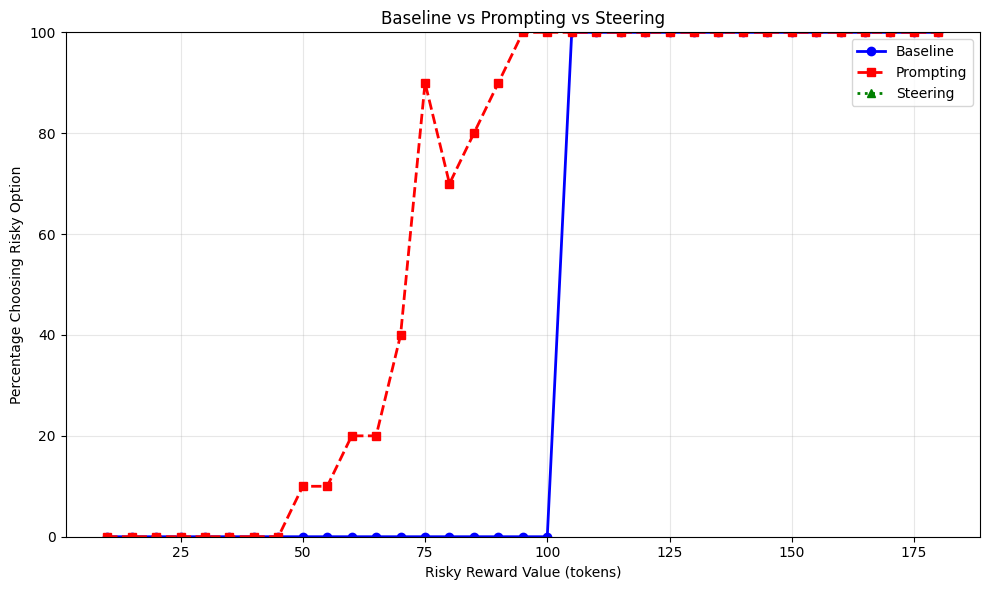

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_safe_risky_choices(directory=None):
    # If no directory specified, find the most recent results folder
    if directory is None:
        base_dir = "mech_interp_games/safe_risky_choice"
        if os.path.exists(base_dir):
            # Find all results directories with timestamps
            results_dirs = [d for d in os.listdir(base_dir) if d.startswith("results_")]
            if results_dirs:
                # Sort by timestamp (newest first)
                results_dirs.sort(reverse=True)
                directory = os.path.join(base_dir, results_dirs[0])
                print(f"Using most recent results directory: {directory}")
            else:
                print("No results directories found!")
                return
        else:
            print("Base directory not found!")
            return
    
    # Identify all relevant files
    files = sorted([f for f in os.listdir(directory) if f.startswith("safe_risky_") and f.endswith(".csv")])

    # Data storage for three conditions
    baseline_data = {}
    prompting_data = {}
    steering_data = {}

    # Process each file
    for file in files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        
        # Compute percentage of "Risky Option"
        total_choices = len(df)
        risky_count = (df["answer.safe_risky_choice"] == "Risky Option").sum()
        risky_percentage = (risky_count / total_choices) * 100
        
        # Extract iteration number from filename
        iteration = int(file.split("_")[-1].split(".")[0])
        
        # Store in appropriate dictionary based on condition
        if "baseline" in file:
            baseline_data[iteration] = risky_percentage
        elif "prompting" in file:
            prompting_data[iteration] = risky_percentage
        elif "steering" in file:
            steering_data[iteration] = risky_percentage

    # Sort by iteration number
    baseline_data = dict(sorted(baseline_data.items()))
    prompting_data = dict(sorted(prompting_data.items()))
    steering_data = dict(sorted(steering_data.items()))

    # Create simple plot
    plt.figure(figsize=(10, 6))
    
    # Plot the three conditions
    plt.plot(baseline_data.keys(), baseline_data.values(), 
             marker="o", linestyle="-", linewidth=2, markersize=6,
             label="Baseline", color='blue')
    
    plt.plot(prompting_data.keys(), prompting_data.values(), 
             marker="s", linestyle="--", linewidth=2, markersize=6,
             label="Prompting", color='red')
    
    plt.plot(steering_data.keys(), steering_data.values(), 
             marker="^", linestyle=":", linewidth=2, markersize=6,
             label="Steering", color='green')

    plt.xlabel("Risky Reward Value (tokens)")
    plt.ylabel("Percentage Choosing Risky Option")
    plt.title("Baseline vs Prompting vs Steering")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    
    plt.tight_layout()
    plt.show()

# Example usage:
plot_safe_risky_choices()  # Automatically uses the most recent results directory


Using most recent results directory: mech_interp_games/safe_risky_choice/results_20250929_194124


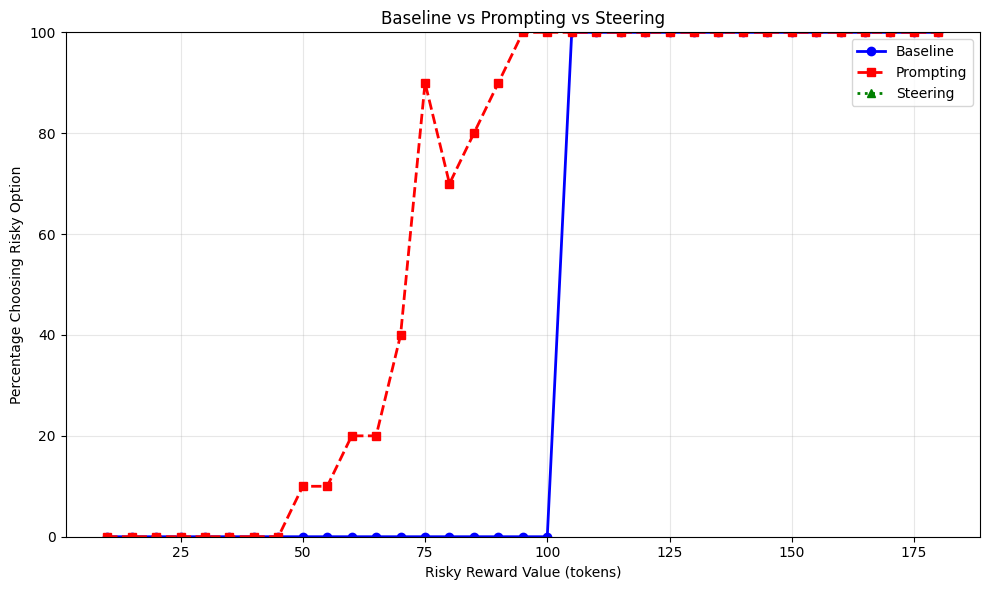

In [10]:
# Plot the results after running experiments
plot_safe_risky_choices()  # Automatically uses the most recent results directory
